# FINAL EXPERIMENT — THREE-TYPE ML PUSH POLICY

Финальная locked-test политика объединяет два **замороженных ML-сигнала** из notebook 28 и один причинный факт из golden methodology:

1. `GOOD_DAY`: frozen ML probability ≥ frozen threshold;
2. `WINDOW_CLOSING`: frozen ML probability ≥ frozen threshold;
3. `POSITIVE_MARKET_FACT`: точный OR трёх фактических условий методологии.

Приоритет: `GOOD_DAY > WINDOW_CLOSING > POSITIVE_MARKET_FACT`. Переиспользуются без настройки на TEST: cooldown 4 календарных дня, максимум 2 push за ISO-неделю и правило, по которому ранее отправленный factual push не блокирует следующий более приоритетный сигнал. Adaptive ranking в frozen policy равен `none`, поэтому здесь он не добавляется.

Метрики считаются только реализациями из `src.backtest.metrics`, то есть строго по `docs/metrics_methodology.md`. Golden labels и future outcomes используются исключительно ретроспективно.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.three_type_push_policy import apply_policy
from src.backtest.metrics import build_outcomes, classification_metrics
from src.backtest.metrics.evaluation import evaluate_schedule

REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures' / 'final_ml_three_type_policy'
FIGURES.mkdir(parents=True, exist_ok=True)

PRED_PATH = REPORTS / 'direct_signal_ml_predictions.parquet'
CONFIG_PATH = REPORTS / 'direct_signal_ml_selected_config.json'
GOLDEN_PATH = ROOT / 'data' / 'labels' / 'golden_labels.parquet'
CALENDAR_PATH = ROOT / 'data' / 'interim' / 'fx_calendar_time.parquet'

config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
pred = pd.read_parquet(PRED_PATH)
golden = pd.read_parquet(GOLDEN_PATH)
calendar = pd.read_parquet(CALENDAR_PATH)
for frame in (pred, golden, calendar):
    frame['date'] = pd.to_datetime(frame['date'])

good_threshold = float(config['selected']['GOOD_DAY']['threshold'])
closing_threshold = float(config['selected']['WINDOW_CLOSING']['threshold'])
assert config['test_used'] is False
print({'good_threshold': good_threshold, 'closing_threshold': closing_threshold,
       'prediction_rows': len(pred), 'test_period': (str(pred.date.min().date()), str(pred.date.max().date()))})

{'good_threshold': 0.8, 'closing_threshold': 0.8, 'prediction_rows': 840, 'test_period': ('2026-01-01', '2026-08-24')}


## Candidate generation и frozen policy

`good_score` и `closing_score` — уже сохранённые TEST probabilities notebook 28. Модели не переобучаются. Фактический сигнал берётся из causal колонок `fact_decline_3_quotes`, `fact_weekly_gain_1pct`, `fact_low_percentile_30d`; будущие столбцы golden dataset до candidate generation отбрасываются.

In [2]:
FACT_COLS = ['fact_decline_3_quotes', 'fact_weekly_gain_1pct', 'fact_low_percentile_30d']
truth_cols = ['corridor', 'date', 'rate', 'good', 'closing', 'positive_market_fact', *FACT_COLS]
required_pred = {'corridor','date','good_score','closing_score','split'}
assert required_pred <= set(pred.columns)
assert set(truth_cols) <= set(golden.columns)
assert pred.duplicated(['corridor','date']).sum() == 0

# Only frozen TEST rows; labels join later as evaluation/reference fields.
x = pred.loc[pred['split'].eq('TEST'), ['corridor','date','good_score','closing_score','split']].copy()
x['good_day_candidate'] = x['good_score'].ge(good_threshold)
x['window_closing_candidate'] = x['closing_score'].ge(closing_threshold)
x = x.merge(golden[truth_cols], on=['corridor','date'], how='left', validate='one_to_one')
assert x[truth_cols].notna().all().all()
x = x.rename(columns={'rate':'rate_t', 'good':'golden_good_day', 'closing':'golden_window_closing',
                      'positive_market_fact':'golden_positive_market_fact'})
x['positive_market_fact_candidate'] = x[FACT_COLS].astype(bool).any(axis=1)
assert x['positive_market_fact_candidate'].eq(x['golden_positive_market_fact'].astype(bool)).all()
x['forecast_high_priority_t1'] = False  # deferral disabled in frozen policy; never reads actual T+1

policy = apply_policy(x, cooldown_days=4, defer_fact=False)
policy['suppressed_by_weekly_cap'] = policy['final_push_reason'].eq('WEEKLY_CAP')
policy['suppressed_by_cooldown_only'] = policy['final_push_reason'].eq('COOLDOWN')
policy['deferred_1d'] = False
policy['policy_version'] = 'ml28-frozen__priority-aware-cooldown4__weekly-cap2__no-adaptive'

assert policy.loc[policy.final_push, 'final_push_type'].isin(['good_day','window_closing','positive_market_fact']).all()
assert not policy['deferred_1d'].any()
print(policy[['good_day_candidate','window_closing_candidate','positive_market_fact_candidate','final_push']].sum())
print(policy.final_push_type.value_counts())

good_day_candidate                127
window_closing_candidate            9
positive_market_fact_candidate    281
final_push                        120
dtype: int64
final_push_type
none                    720
positive_market_fact     66
good_day                 47
window_closing            7
Name: count, dtype: int64


## Метрики по актуальной methodology

Для ML-типов используются classification metrics (`precision`, `recall`, `F0.5`, average precision, classification lift). Для factual-типа classification quality не интерпретируется: его candidate является самим наблюдаемым фактом. Для всех отправленных push рассчитываются safety, closing confirmation и economic benefit на горизонтах 1/3/5/10/20 календарных дней, а baseline — 1000 разрешённых случайных расписаний с тем же числом push, cooldown и weekly cap.

In [3]:
# Classification of FINAL delivered ML pushes.
classification_rows = []
for scope, group in [('PORTFOLIO', policy), *policy.groupby('corridor', sort=True)]:
    for signal_type, truth_col, score_col in [
        ('GOOD_DAY','golden_good_day','good_score'),
        ('WINDOW_CLOSING','golden_window_closing','closing_score'),
    ]:
        final_signal = group.final_push & group.final_push_type.eq(signal_type.lower())
        m = classification_metrics(group[truth_col].astype(bool), final_signal, y_score=group[score_col], beta=.5)
        classification_rows.append({'metric_family':'classification','scope':scope,'signal_type':signal_type,**m})

# Factual rows are auditable counts, not classification scores.
for scope, group in [('PORTFOLIO', policy), *policy.groupby('corridor', sort=True)]:
    fact_signal = group.final_push & group.final_push_type.eq('positive_market_fact')
    classification_rows.append({
        'metric_family':'factual_count','scope':scope,'signal_type':'POSITIVE_MARKET_FACT',
        'rows':len(group),'predicted_positive':int(fact_signal.sum()),
        'actual_positive':int(group.golden_positive_market_fact.astype(bool).sum()),
        'true_positive':int((fact_signal & group.golden_positive_market_fact.astype(bool)).sum()),
        'false_positive':np.nan,'false_negative':np.nan,'true_negative':np.nan,
        'precision':np.nan,'recall':np.nan,'f_beta':np.nan,'beta':.5,
        'prevalence':float(group.golden_positive_market_fact.mean()),'random_precision':np.nan,
        'classification_lift':np.nan,'average_precision':np.nan,
    })
classification_table = pd.DataFrame(classification_rows)

# Outcome and policy-matched random metrics, one corridor at a time.
cal = calendar.copy()
if 'corridor' not in cal:
    cal['corridor'] = cal['currency'].astype(str) + '_RUB'
if 'rate' not in cal:
    cal = cal.rename(columns={'unit_rate':'rate'})
outcome_parts, random_parts = [], []
scenario_map = {'good_day':'good_now','window_closing':'window_closing','positive_market_fact':'positive_market_fact'}
for idx, (corridor, group) in enumerate(policy.groupby('corridor', sort=True)):
    candidates = group[['date','corridor','rate_t']].rename(columns={'rate_t':'rate'})
    outcomes = build_outcomes(candidates, cal[['date','corridor','rate']])
    pushes = group.loc[group.final_push, ['date','final_push_type']].rename(columns={'final_push_type':'push_scenario'})
    pushes['push_scenario'] = pushes.push_scenario.map(scenario_map)
    metrics, random_runs = evaluate_schedule(
        pushes, outcomes, group.date, replicates=1000, cooldown_days=4, weekly_cap=2, seed=42+idx
    )
    metrics.insert(0,'scope',corridor); random_runs.insert(0,'scope',corridor)
    outcome_parts.append(metrics); random_parts.append(random_runs)
outcome_table = pd.concat(outcome_parts, ignore_index=True)
random_table = pd.concat(random_parts, ignore_index=True)

metrics_export = pd.concat([classification_table, outcome_table.assign(metric_family='outcome')], ignore_index=True, sort=False)
display(classification_table.query("scope == 'PORTFOLIO'")[['signal_type','predicted_positive','actual_positive','true_positive','false_positive','false_negative','precision','recall','f_beta','average_precision','classification_lift']])
display(outcome_table.query("h_days == 10")[['scope','scenario','signal_count','safety_hit_rate','random_safety_hit_rate_mean','safety_lift','closing_confirmation_hit_rate','benefit_mean_bps','incremental_benefit_bps']])

,signal_type,predicted_positive,actual_positive,true_positive,false_positive,false_negative,precision,recall,f_beta,average_precision,classification_lift
0,GOOD_DAY,47,203,20,27.0,183.0,0.425532,0.098522,0.255754,0.505140,1.760822
1,WINDOW_CLOSING,7,52,1,6.0,51.0,0.142857,0.019231,0.062500,0.140667,2.307692
12,POSITIVE_MARKET_FACT,66,281,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,scope,scenario,signal_count,safety_hit_rate,random_safety_hit_rate_mean,safety_lift,closing_confirmation_hit_rate,benefit_mean_bps,incremental_benefit_bps
3,AMD_RUB,good_now,10,0.500000,0.607900,0.822504,NaN,19.003696,15.913028
8,AMD_RUB,positive_market_fact,13,0.615385,0.608769,1.010867,NaN,70.140212,67.792892
13,AMD_RUB,window_closing,1,1.000000,0.598000,1.672241,0.000000,-38.924050,-39.720510
18,AMD_RUB,portfolio,24,0.583333,0.612417,0.952511,NaN,44.288986,40.680952
23,KGS_RUB,good_now,11,0.454545,0.592273,0.767460,NaN,-1.636183,-3.499266
28,KGS_RUB,positive_market_fact,13,0.615385,0.585769,1.050558,NaN,77.427590,76.669692
33,KGS_RUB,window_closing,1,0.000000,0.611000,0.000000,0.000000,-108.984939,-111.466479
38,KGS_RUB,portfolio,25,0.520000,0.590640,0.880401,NaN,35.183028,32.674746
43,KZT_RUB,positive_market_fact,15,0.666667,0.508867,1.310101,NaN,75.347307,73.738331
48,KZT_RUB,good_now,6,0.333333,0.510167,0.653381,NaN,73.256061,69.718558


## Частота и suppression

Месячная таблица строится по полному `corridor × month` индексу, включая месяцы без push. `suppressed_by_priority` означает наличие нескольких same-day candidates; `suppressed_by_cooldown_only` и `suppressed_by_weekly_cap` показываются раздельно.

In [4]:
policy['month'] = policy.date.dt.to_period('M').astype(str)
types = ['good_day','window_closing','positive_market_fact']
month_index = pd.MultiIndex.from_product([sorted(policy.corridor.unique()), sorted(policy.month.unique())], names=['corridor','month']).to_frame(index=False)
monthly = (policy.loc[policy.final_push].groupby(['corridor','month','final_push_type']).size()
           .unstack(fill_value=0).reset_index())
monthly = month_index.merge(monthly, on=['corridor','month'], how='left').fillna(0)
for col in types:
    if col not in monthly: monthly[col] = 0
monthly['total_pushes'] = monthly[types].sum(axis=1).astype(int)

suppression = policy.loc[
    policy.suppressed_by_priority | policy.suppressed_by_cooldown | policy.deferred_1d,
    ['corridor','date','good_day_candidate','window_closing_candidate','positive_market_fact_candidate',
     'suppressed_by_priority','suppressed_by_cooldown_only','suppressed_by_weekly_cap','deferred_1d',
     'final_push','final_push_type','final_push_reason']
].copy()

frequency_summary = {
    'total_pushes': int(policy.final_push.sum()),
    'mean_pushes_per_corridor_month': float(monthly.total_pushes.mean()),
    'median_pushes_per_corridor_month': float(monthly.total_pushes.median()),
    'share_corridor_months_ge_3': float(monthly.total_pushes.ge(3).mean()),
    'zero_push_months': int(monthly.total_pushes.eq(0).sum()),
    'suppressed_by_priority_rows': int(policy.suppressed_by_priority.sum()),
    'suppressed_by_cooldown_only': int(policy.suppressed_by_cooldown_only.sum()),
    'suppressed_by_weekly_cap': int(policy.suppressed_by_weekly_cap.sum()),
}
frequency_summary

{'total_pushes': 120,
 'mean_pushes_per_corridor_month': 3.0,
 'median_pushes_per_corridor_month': 3.0,
 'share_corridor_months_ge_3': 0.625,
 'zero_push_months': 1,
 'suppressed_by_priority_rows': 87,
 'suppressed_by_cooldown_only': 210,
 'suppressed_by_weekly_cap': 0}

## Визуализации по коридорам

На первом графике показаны все кандидаты до communication policy. На втором — только доставленные push: звезда означает TP, красный крест — FP, пустой перевёрнутый треугольник — пропущенный golden event соответствующего типа.

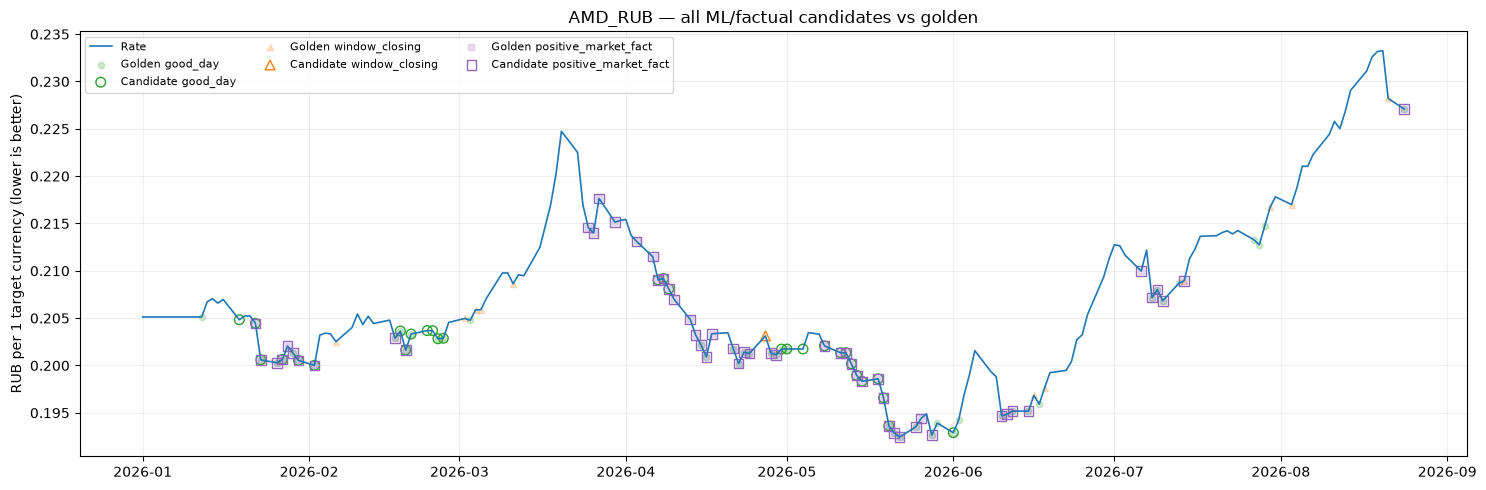

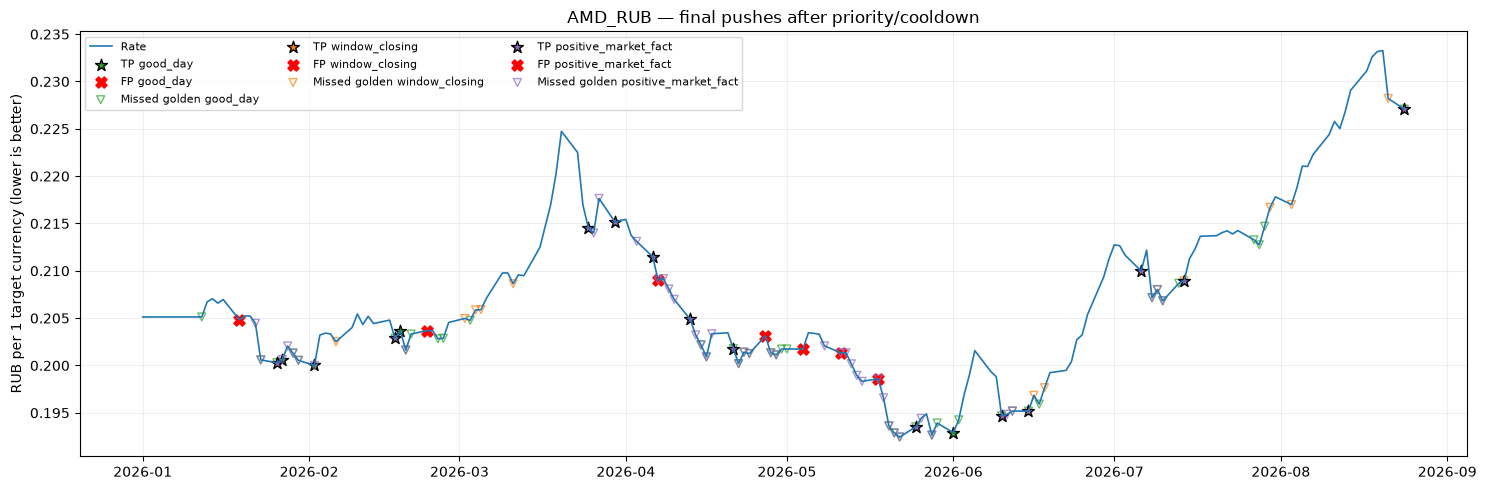

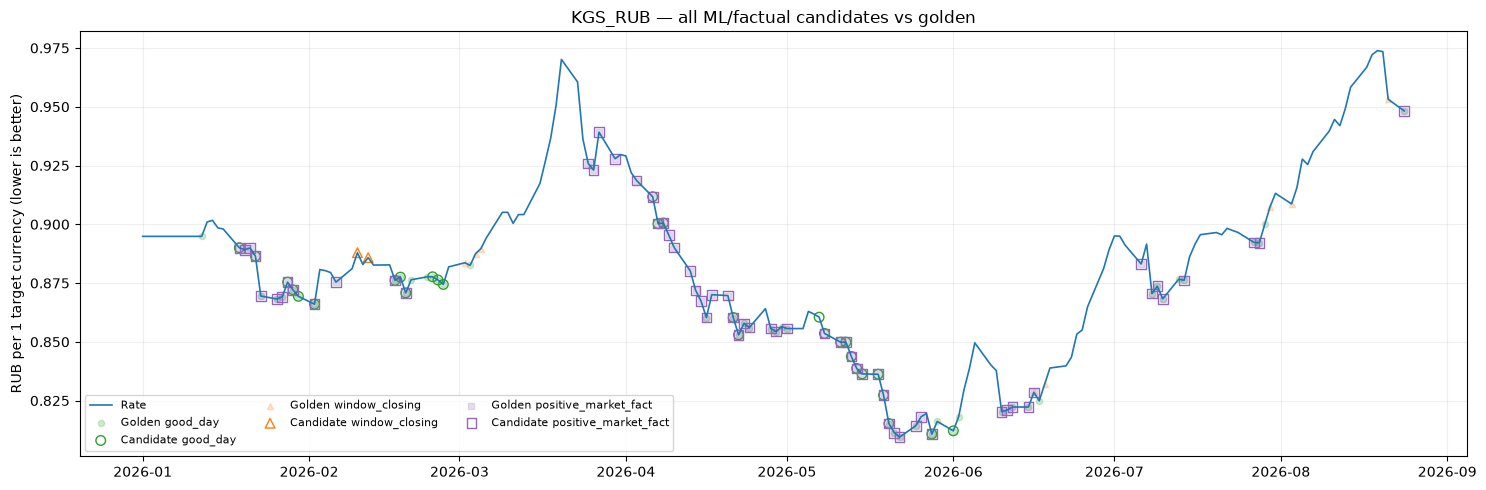

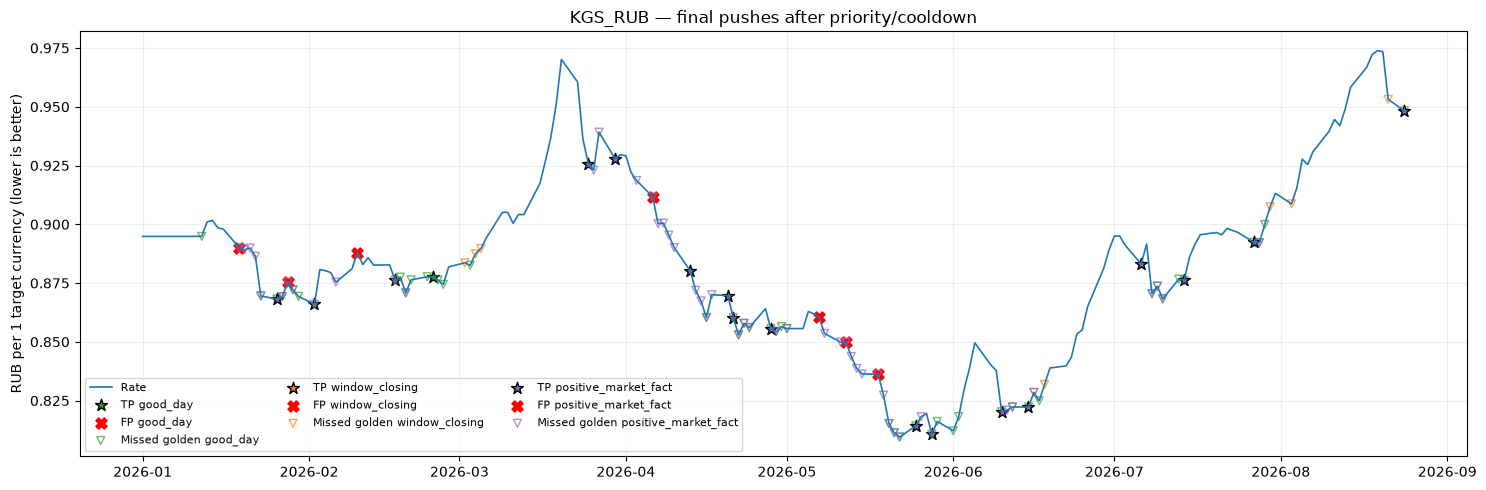

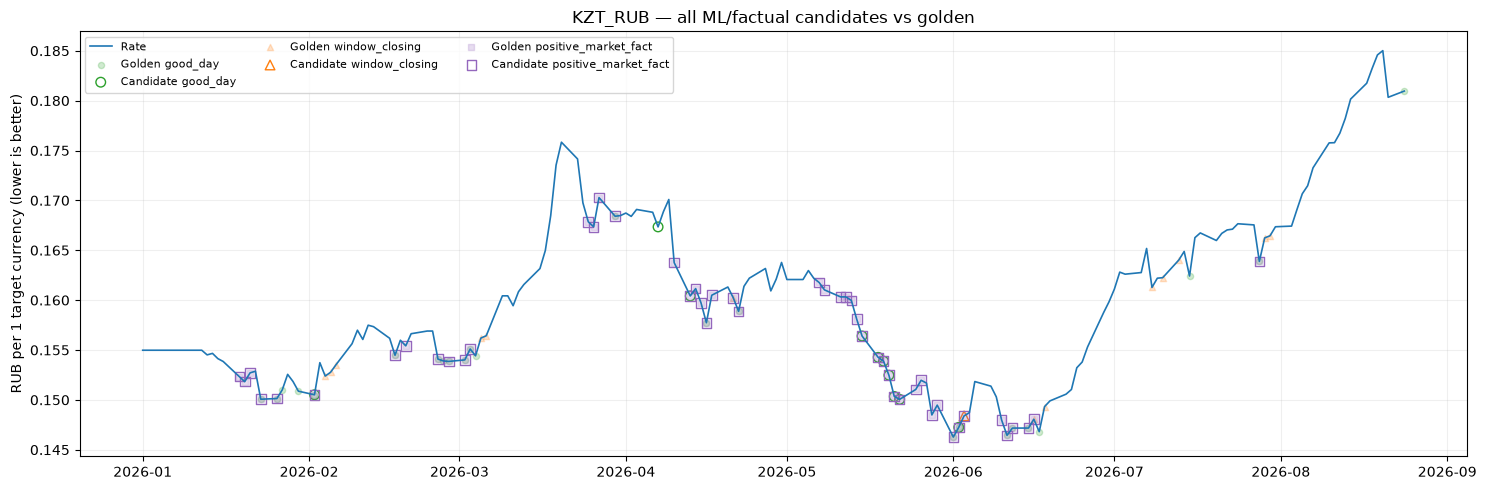

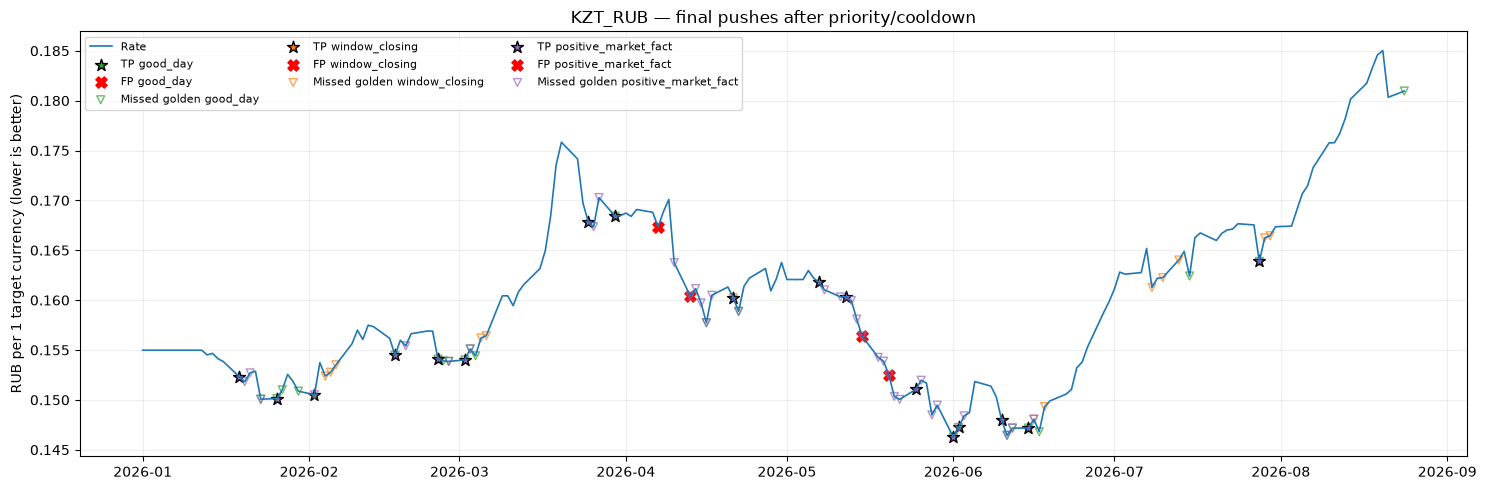

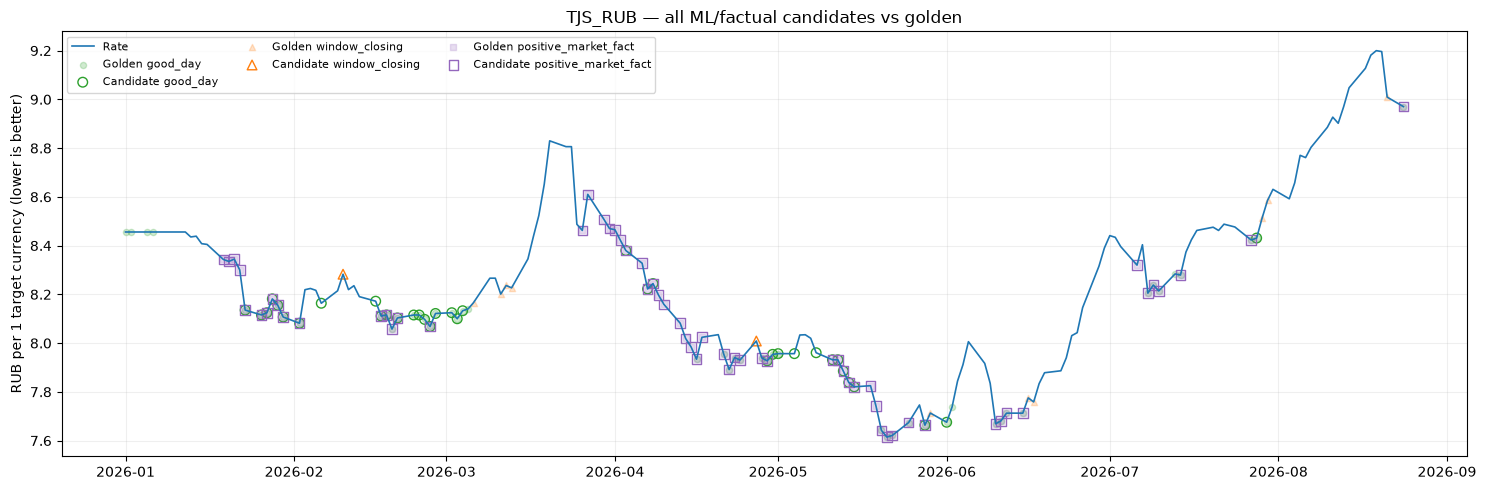

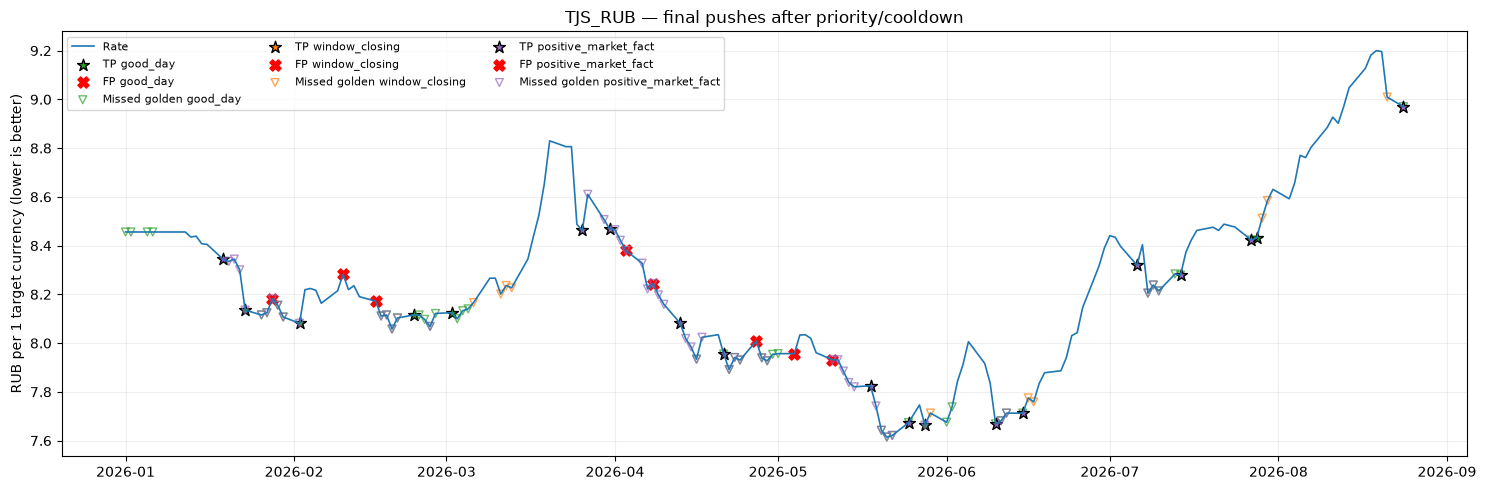

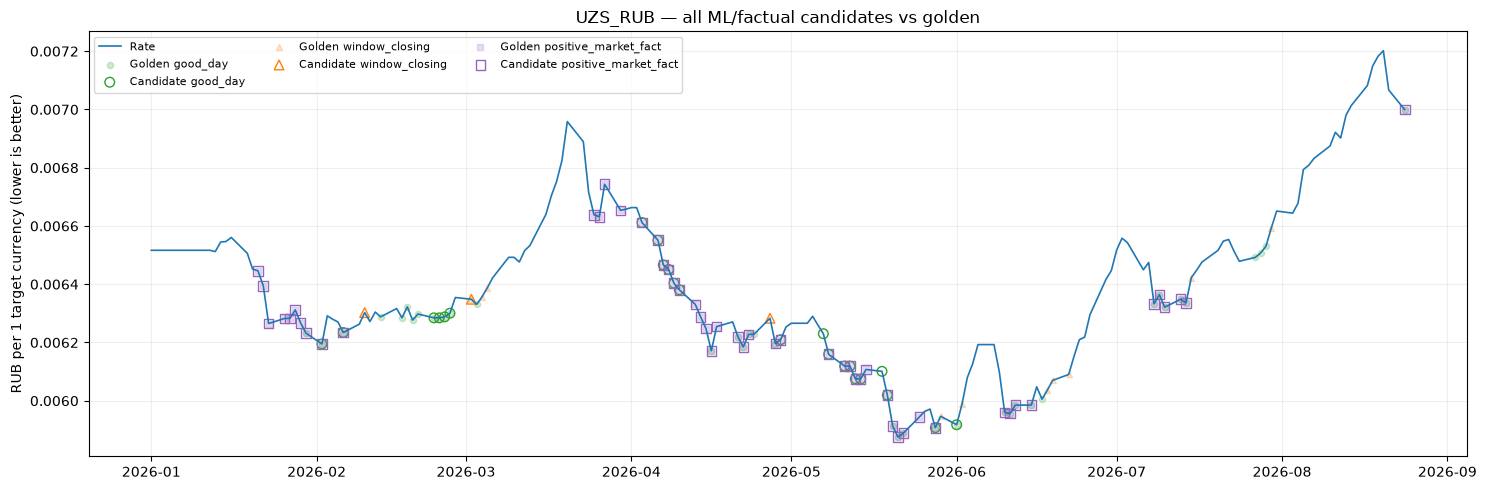

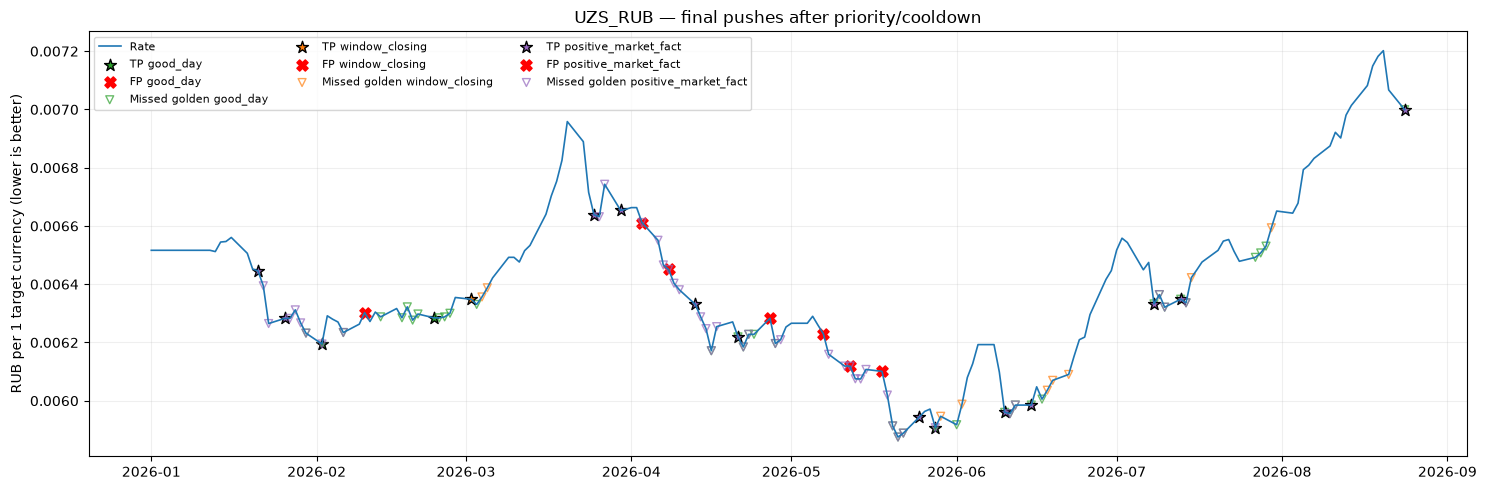

Saved: C:\Users\dasha\itmo_hackaton\team-2-aitalenthack\reports\figures\final_ml_three_type_policy


In [5]:
COLORS = {'good_day':'#2ca02c','window_closing':'#ff7f0e','positive_market_fact':'#9467bd'}
MARKERS = {'good_day':'o','window_closing':'^','positive_market_fact':'s'}
MAP = {
 'good_day':('good_day_candidate','golden_good_day'),
 'window_closing':('window_closing_candidate','golden_window_closing'),
 'positive_market_fact':('positive_market_fact_candidate','golden_positive_market_fact')}

for corridor, g in policy.groupby('corridor', sort=True):
    fig, ax = plt.subplots(figsize=(15,5)); ax.plot(g.date,g.rate_t,color='#1f77b4',lw=1.2,label='Rate')
    for typ,(cand,truth) in MAP.items():
        q=g[g[truth].astype(bool)]; ax.scatter(q.date,q.rate_t,s=20,color=COLORS[typ],alpha=.22,marker=MARKERS[typ],label=f'Golden {typ}')
        q=g[g[cand].astype(bool)]; ax.scatter(q.date,q.rate_t,s=48,facecolors='none',edgecolors=COLORS[typ],marker=MARKERS[typ],label=f'Candidate {typ}')
    ax.set(title=f'{corridor} — all ML/factual candidates vs golden', ylabel='RUB per 1 target currency (lower is better)')
    ax.grid(alpha=.2); ax.legend(ncol=3,fontsize=8); fig.tight_layout(); fig.savefig(FIGURES/f'{corridor}_all_candidates.png',dpi=150); plt.show(); plt.close(fig)

    fig, ax = plt.subplots(figsize=(15,5)); ax.plot(g.date,g.rate_t,color='#1f77b4',lw=1.2,label='Rate')
    for typ,(_,truth) in MAP.items():
        target=g[truth].astype(bool); delivered=g.final_push & g.final_push_type.eq(typ)
        tp=g[target & delivered]; fp=g[~target & delivered]; missed=g[target & ~delivered]
        ax.scatter(tp.date,tp.rate_t,s=80,color=COLORS[typ],marker='*',edgecolors='black',label=f'TP {typ}')
        ax.scatter(fp.date,fp.rate_t,s=65,color='red',marker='X',label=f'FP {typ}')
        ax.scatter(missed.date,missed.rate_t,s=32,facecolors='none',edgecolors=COLORS[typ],marker='v',alpha=.7,label=f'Missed golden {typ}')
    ax.set(title=f'{corridor} — final pushes after priority/cooldown', ylabel='RUB per 1 target currency (lower is better)')
    ax.grid(alpha=.2); ax.legend(ncol=3,fontsize=8); fig.tight_layout(); fig.savefig(FIGURES/f'{corridor}_final_pushes.png',dpi=150); plt.show(); plt.close(fig)
print('Saved:', FIGURES)

## Сохранение воспроизводимых результатов и leakage audit

In [6]:
prediction_cols = ['corridor','date','rate_t','good_score','closing_score','good_day_candidate','window_closing_candidate',
 'positive_market_fact_candidate',*FACT_COLS,'golden_good_day','golden_window_closing','golden_positive_market_fact',
 'suppressed_by_priority','suppressed_by_cooldown_only','suppressed_by_weekly_cap','deferred_1d','final_push','final_push_type','final_push_reason','policy_version']
policy[prediction_cols].to_csv(REPORTS/'final_ml_three_type_predictions.csv',index=False)
metrics_export.to_csv(REPORTS/'final_ml_three_type_metrics.csv',index=False)
monthly.to_csv(REPORTS/'final_ml_three_type_monthly.csv',index=False)
suppression.to_csv(REPORTS/'final_ml_three_type_suppression.csv',index=False)

portfolio = classification_table.query("scope == 'PORTFOLIO'").set_index('signal_type')
lines = [
'# Финальная трёхтиповая ML push policy', '',
'## Frozen configuration', '',
f'- GOOD_DAY: CatBoost probability >= {good_threshold}',
f'- WINDOW_CLOSING: CatBoost probability >= {closing_threshold}',
'- POSITIVE_MARKET_FACT: точный causal OR factual flags из golden methodology',
'- Priority: good_day > window_closing > positive_market_fact',
'- Cooldown: 4 календарных дня; cap: 2 push/ISO-неделю; adaptive ranking: none', '',
'## Classification (final delivered ML pushes)', '',
portfolio[['predicted_positive','actual_positive','true_positive','false_positive','false_negative','precision','recall','f_beta','average_precision','classification_lift']].to_markdown(), '',
'POSITIVE_MARKET_FACT не получает classification precision/recall: согласно metrics methodology это детерминированный наблюдаемый факт, а не прогноз.', '',
'## Frequency', '', *[f'- {k}: {v}' for k,v in frequency_summary.items()], '',
'## Leakage audit', '',
'- Frozen notebook 28 TEST probabilities read from disk; no fitting or threshold selection.',
'- Golden labels and future outcomes are used only for plots/evaluation.',
'- Factual candidates use only flags available at T.',
'- Priority/cooldown/weekly cap are frozen and not optimized on TEST.',
'- Deferral is disabled; actual T+1 is never used.', '',
'**LEAKAGE CHECK: PASS**',
]
(REPORTS/'final_ml_three_type_report.md').write_text('\n'.join(lines),encoding='utf-8')

print('GOOD_DAY metrics'); display(portfolio.loc[['GOOD_DAY']])
print('WINDOW_CLOSING metrics'); display(portfolio.loc[['WINDOW_CLOSING']])
print('POSITIVE_MARKET_FACT metrics (factual count + outcomes; classification N/A)'); display(portfolio.loc[['POSITIVE_MARKET_FACT']])
print('COMBINED policy metrics'); print(frequency_summary)
print('LEAKAGE CHECK: PASS')

GOOD_DAY metrics


,metric_family,scope,rows,true_positive,false_positive,false_negative,true_negative,predicted_positive,actual_positive,precision,recall,f_beta,beta,prevalence,random_precision,classification_lift,average_precision
signal_type,,,,,,,,,,,,,,,,,
GOOD_DAY,classification,PORTFOLIO,840,20,27.0,183.0,610.0,47,203,0.425532,0.098522,0.255754,0.5,0.241667,0.241667,1.760822,0.50514


WINDOW_CLOSING metrics


,metric_family,scope,rows,true_positive,false_positive,false_negative,true_negative,predicted_positive,actual_positive,precision,recall,f_beta,beta,prevalence,random_precision,classification_lift,average_precision
signal_type,,,,,,,,,,,,,,,,,
WINDOW_CLOSING,classification,PORTFOLIO,840,1,6.0,51.0,782.0,7,52,0.142857,0.019231,0.0625,0.5,0.061905,0.061905,2.307692,0.140667


POSITIVE_MARKET_FACT metrics (factual count + outcomes; classification N/A)


,metric_family,scope,rows,true_positive,false_positive,false_negative,true_negative,predicted_positive,actual_positive,precision,recall,f_beta,beta,prevalence,random_precision,classification_lift,average_precision
signal_type,,,,,,,,,,,,,,,,,
POSITIVE_MARKET_FACT,factual_count,PORTFOLIO,840,66,NaN,NaN,NaN,66,281,NaN,NaN,NaN,0.5,0.334524,NaN,NaN,NaN


COMBINED policy metrics
{'total_pushes': 120, 'mean_pushes_per_corridor_month': 3.0, 'median_pushes_per_corridor_month': 3.0, 'share_corridor_months_ge_3': 0.625, 'zero_push_months': 1, 'suppressed_by_priority_rows': 87, 'suppressed_by_cooldown_only': 210, 'suppressed_by_weekly_cap': 0}
LEAKAGE CHECK: PASS
